# 05 · Feature Selection & Feature Engineering

> Part of the **Data Preprocessing** module — taught alongside the `data/customer_churn.csv` dataset.

## Learning objectives
- Engineer new features from domain knowledge (ratios, bins, flags)
- Use filter, wrapper, and embedded methods to *select* features
- Read tree-based feature importance correctly (and its limits)
- Use L1 (Lasso) regularisation as automatic selection

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

df = pd.read_csv("data/customer_churn.csv")
print("shape:", df.shape)
df.head()

shape: (5000, 15)


,customer_id,age,gender,city,education,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,10000,46.0,Male,Bengaluru,Bachelors,40,Month-to-month,Electronic check,16.90,686.72,3,1,0,55083.68,1
1,10001,28.0,Female,Chennai,Masters,22,One year,Credit card,88.73,NaN,2,1,0,75325.39,0
2,10002,52.0,Female,Mumbai,Bachelors,7,Two year,Mailed check,67.45,449.61,1,1,1,57584.71,0
3,10003,54.0,Male,Delhi,Bachelors,31,One year,Bank transfer,48.61,1615.53,1,1,0,57525.63,0
4,10004,18.0,Male,Delhi,Bachelors,18,Month-to-month,Bank transfer,90.82,1612.81,1,1,0,103508.09,0


## Part A — Feature Engineering

Often the single biggest lever in a tabular project. The model can only see the columns
you give it; if the right transform isn't there, the model can't learn it well.

### 1. Domain-driven features
Combinations and ratios that capture business meaning.

In [2]:
feats = df.copy()
feats["tenure_years"]      = feats["tenure_months"] / 12
feats["charges_per_month"] = feats["total_charges"] / feats["tenure_months"].replace(0, np.nan)
feats["high_value"]        = (feats["monthly_charges"] > feats["monthly_charges"].quantile(0.75)).astype(int)
feats["new_customer"]      = (feats["tenure_months"] <= 6).astype(int)

feats[["tenure_months", "tenure_years", "monthly_charges",
       "charges_per_month", "high_value", "new_customer"]].head()

,tenure_months,tenure_years,monthly_charges,charges_per_month,high_value,new_customer
0,40,3.333333,16.90,17.168000,0,0
1,22,1.833333,88.73,NaN,1,0
2,7,0.583333,67.45,64.230000,0,0
3,31,2.583333,48.61,52.113871,0,0
4,18,1.500000,90.82,89.600556,1,0


### 2. Binning continuous variables

Useful when the relationship with the target is non-linear and you're using a linear
model. `pd.cut` for fixed bins, `pd.qcut` for quantile-based bins.

In [3]:
feats["age_group"] = pd.cut(
    feats["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["<25", "25-34", "35-49", "50-64", "65+"],
)
feats["age_group"].value_counts().sort_index()

age_group
<25       488
25-34     946
35-49    2063
50-64     941
65+       162
Name: count, dtype: int64

### 3. Interaction features
Sometimes two columns matter only in combination.

In [4]:
feats["active_x_contract"] = feats["is_active_member"].astype(str) + "_" + feats["contract_type"]
feats["active_x_contract"].value_counts()

active_x_contract
1_Month-to-month    1514
0_Month-to-month    1235
1_One year           681
0_One year           575
1_Two year           545
0_Two year           450
Name: count, dtype: int64

### 4. Log / power transforms
For long-tailed numeric features. Already covered in notebook 02 — bring it back into
your engineering toolkit.

In [5]:
feats["log_estimated_salary"] = np.log1p(feats["estimated_salary"])

---
## Part B — Feature Selection

Three families:

- **Filter** — score each feature against the target, keep the top ones. Cheap, model-agnostic.
- **Wrapper** — train a model on different feature subsets. Expensive but accurate.
- **Embedded** — selection happens *inside* the model (Lasso, tree importances).

(5000, 15)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

X = df.drop(columns=["customer_id", "churned"])
y = df["churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

pre = ColumnTransformer(
    [
        (
            "numerical",
            Pipeline(
                [("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]
            ),
            numeric_cols,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            cat_cols,
        ),
    ]
)
X_train_p = pre.fit_transform(X_train)
X_test_p = pre.transform(X_test)
feat_names = pre.get_feature_names_out()
print("Total features after preprocessing:", X_train_p.shape[1])

Total features after preprocessing: 27


### 5. Filter — Variance Threshold
Drops near-constant features (no information to learn from).

In [7]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_train_p)
print(f"{X_train_p.shape[1]}  →  {X_vt.shape[1]} features (dropped near-constants)")

27  →  27 features (dropped near-constants)


### 6. Filter — Univariate (ANOVA F / mutual information)

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

skb = SelectKBest(score_func=f_classif, k=15).fit(X_train_p, y_train)
top = pd.Series(skb.scores_, index=feat_names).sort_values(ascending=False).head(15)
top.round(2)

num__tenure_months                      84.22
cat__contract_type_Month-to-month       69.25
num__is_active_member                   43.11
cat__contract_type_Two year             40.77
num__total_charges                      36.85
cat__payment_method_Electronic check    18.46
cat__contract_type_One year             13.16
num__num_products                       12.04
num__monthly_charges                     8.94
cat__city_Chennai                        7.97
cat__payment_method_Bank transfer        3.80
cat__payment_method_Credit card          3.21
cat__city_Delhi                          2.17
num__estimated_salary                    1.71
cat__education_PhD                       1.54
dtype: float64

### 7. Filter — Correlation
Drop highly correlated numeric features (one of each redundant pair).

In [9]:
corr = pd.DataFrame(X_train_p, columns=feat_names).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.9).any()]
print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: ['cat__gender_Male']


### 8. Wrapper — Recursive Feature Elimination (RFE)
Trains a model, drops the weakest feature, repeats. Slower but uses model performance
directly.

In [10]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=10)
rfe.fit(X_train_p, y_train)
selected = pd.Series(feat_names)[rfe.support_].tolist()
print("RFE chose:", selected)

RFE chose: ['num__tenure_months', 'num__monthly_charges', 'num__num_products', 'num__is_active_member', 'num__estimated_salary', 'cat__city_Chennai', 'cat__education_PhD', 'cat__contract_type_Month-to-month', 'cat__contract_type_Two year', 'cat__payment_method_Electronic check']


### 9. Embedded — tree-based importance

Random forest gives one importance per feature based on how much it reduces impurity.
Fast and respects interactions.

**Watch out**: importance is biased toward high-cardinality features. Always sanity-check
against permutation importance for the model you actually care about.

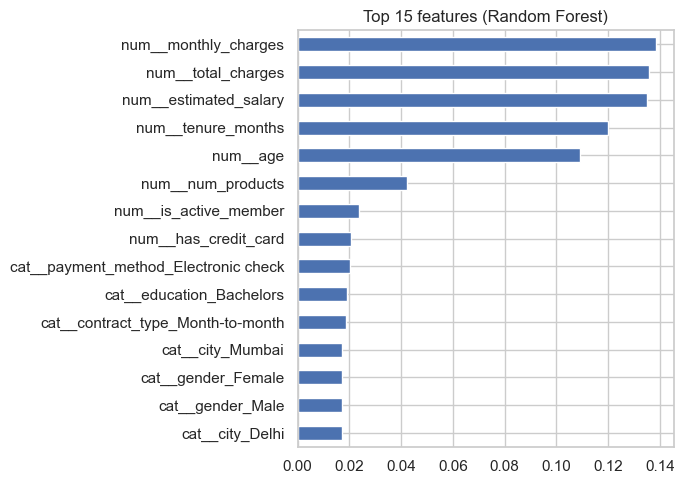

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_p, y_train)

imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=True).tail(15)
imp.plot(kind="barh", figsize=(7, 5)); plt.title("Top 15 features (Random Forest)")
plt.tight_layout(); plt.show()

### 10. Embedded — L1 (Lasso) regularisation
Shrinks unimportant coefficients to *exactly zero* — selection comes for free.

In [12]:
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(penalty="l1", solver="saga", C=0.3, max_iter=2000)
lasso.fit(X_train_p, y_train)

coef = pd.Series(lasso.coef_[0], index=feat_names)
print("Non-zero coefficients:", (coef != 0).sum(), "of", len(coef))
coef[coef != 0].sort_values(key=abs, ascending=False).head(10)

c:\Users\Vineet Tiwari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Vineet Tiwari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Non-zero coefficients: 16 of 27


cat__contract_type_Month-to-month       0.764451
num__tenure_months                     -0.583450
cat__contract_type_Two year            -0.538616
cat__payment_method_Electronic check    0.473947
cat__city_Chennai                      -0.403419
num__is_active_member                  -0.386557
num__num_products                       0.175679
num__monthly_charges                    0.134132
num__estimated_salary                  -0.087764
cat__education_Bachelors               -0.072060
dtype: float64

### 11. Permutation importance — the trustworthy one
Shuffles one feature at a time and measures how much performance drops. Slower but
unbiased and works for any model.

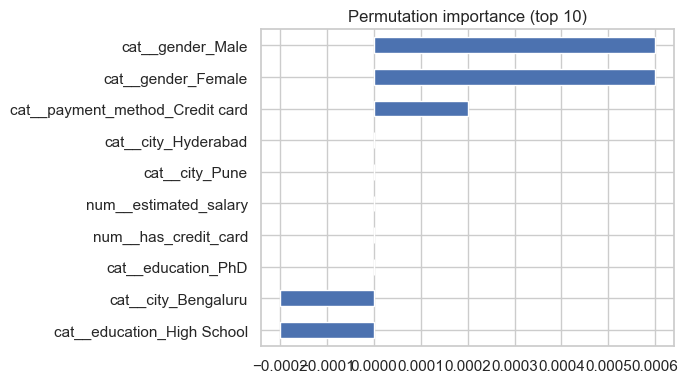

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test_p, y_test, n_repeats=5,
                              random_state=42, n_jobs=-1)
pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=True).tail(10) \
   .plot(kind="barh", figsize=(7, 4)); plt.title("Permutation importance (top 10)")
plt.tight_layout(); plt.show()

## Cheat sheet

| Goal | Technique |
|------|-----------|
| Drop dead-weight features fast | `VarianceThreshold` |
| Quick numeric ranking | `SelectKBest(f_classif)` / mutual info |
| Remove redundant features | correlation filter (>0.9) |
| Best subset, slow | RFE / forward / backward |
| Linear model selection | L1 (Lasso) |
| Honest importance for any model | permutation importance |

## Exercise
1. Pick the top-10 features from L1 vs RFE vs RF importance. How much do the three lists overlap?
2. Engineer two new features you think should help. Re-run RF importance — did they make the cut?